In [1]:
import numpy as np
import pandas as pd

import IPython.display as dp
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
sns.despine()

plt.rc("figure", figsize=(12, 8))
plt.rc("font", size=13)

%matplotlib inline

<Figure size 640x480 with 0 Axes>

In [3]:
!pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.8/344.8 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [12]:
!pip install astsadata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.8/473.8 kB 5.3 MB/s eta 0:00:00


In [127]:
from darts import TimeSeries
import darts.datasets as ds
import scipy.stats as sts
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
from darts.utils.statistics import plot_acf, plot_pacf, check_seasonality

In [24]:
from datetime import date

In [51]:
from astsadata import UnempRate, djia

In [3]:
air_pax = ds.AirPassengersDataset().load()

In [4]:
air_pax_log = air_pax.map(lambda ts, x: np.log(x))

In [5]:
train, val = air_pax.split_before(pd.Timestamp("19580101"))

In [29]:
UnempRate = UnempRate.set_axis(
    pd.date_range(
      date(UnempRate.index[0].year, UnempRate.index[0].month, 1),
      date(UnempRate.index[-1].year, UnempRate.index[-1].month, 1),
      freq="MS"
  ),
  axis=0
)

In [31]:
unemp_rate = TimeSeries.from_dataframe(UnempRate)

<Axes: xlabel='time'>

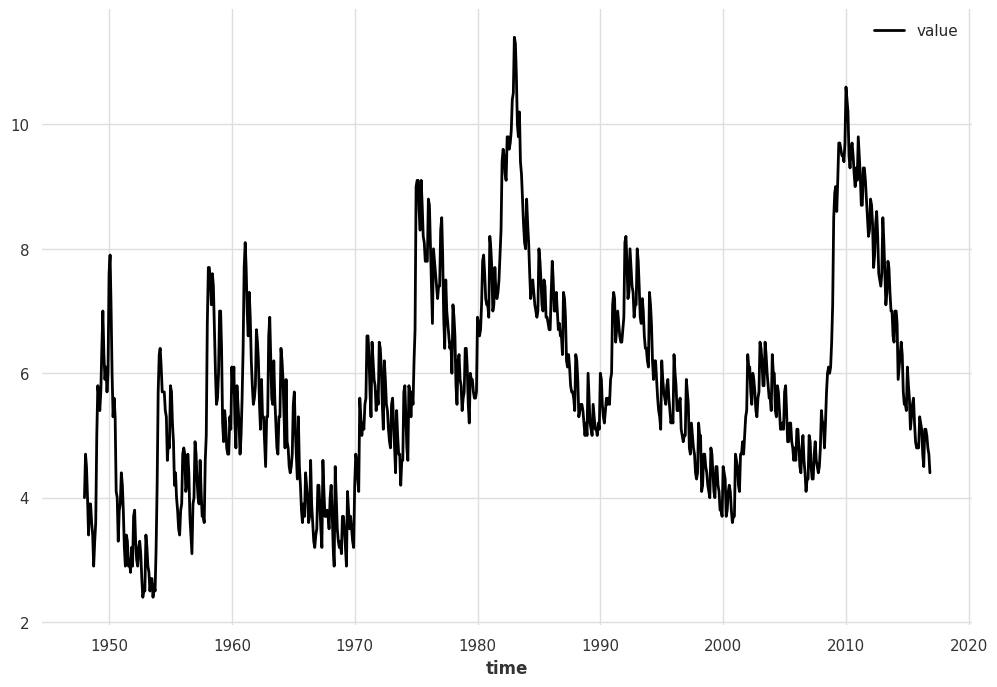

In [213]:
unemp_rate.plot()

In [74]:
djia = djia.set_axis([
    date(i.year, i.month, i.day) for i in djia.index
], axis=0).reset_index().drop_duplicates("index").set_index("index")

In [78]:
djia = djia.reindex(
  pd.date_range(
      djia.index[0],
      djia.index[-1],
      freq='D'
  )
).fillna(
  method="ffill"
)

/tmp/ipython-input-1924615743.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ).fillna(


In [88]:
dow_jones = TimeSeries.from_dataframe(djia[["Close"]])

<Axes: xlabel='time'>

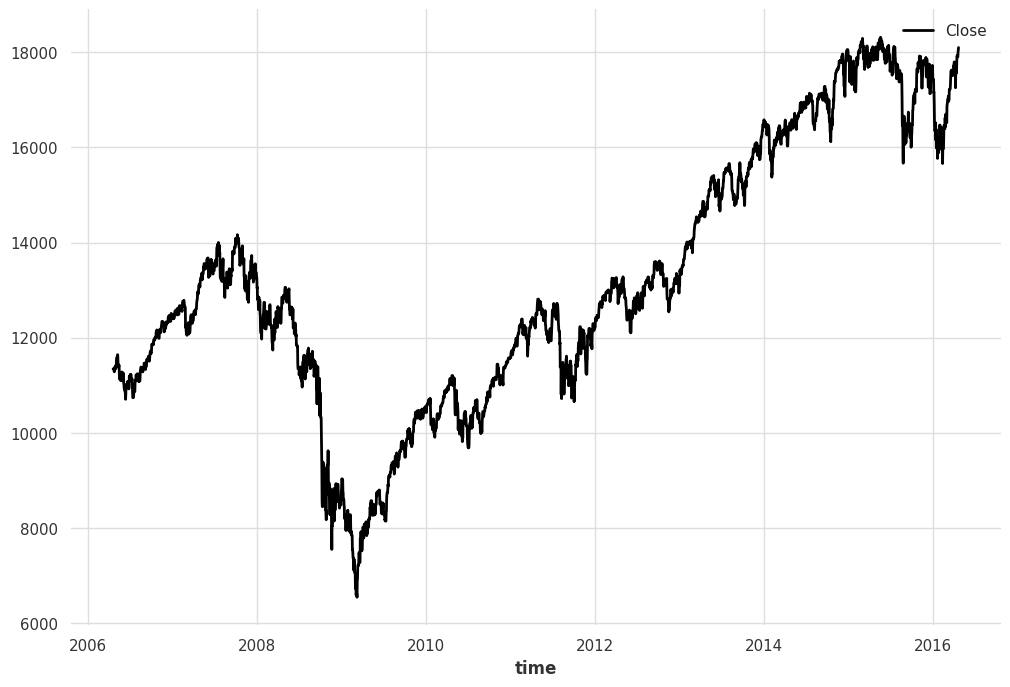

In [214]:
dow_jones.plot()

# Webinar

## STL decomposition

In [215]:
print(tsa.STL.__doc__)


    STL(endog, period=None, seasonal=7, trend=None, low_pass=None,
        seasonal_deg=1, trend_deg=1, low_pass_deg=1, robust=False,
        seasonal_jump=1, trend_jump=1, low_pass_jump=1)

    Season-Trend decomposition using LOESS.

    Parameters
    ----------
    endog : array_like
        Data to be decomposed. Must be squeezable to 1-d.
    period : {int, None}, optional
        Periodicity of the sequence. If None and endog is a pandas Series or
        DataFrame, attempts to determine from endog. If endog is a ndarray,
        period must be provided.
    seasonal : int, optional
        Length of the seasonal smoother. Must be an odd integer, and should
        normally be >= 7 (default).
    trend : {int, None}, optional
        Length of the trend smoother. Must be an odd integer. If not provided
        uses the smallest odd integer greater than
        1.5 * period / (1 - 1.5 / seasonal), following the suggestion in
        the original implementation.
    low_pass : {i

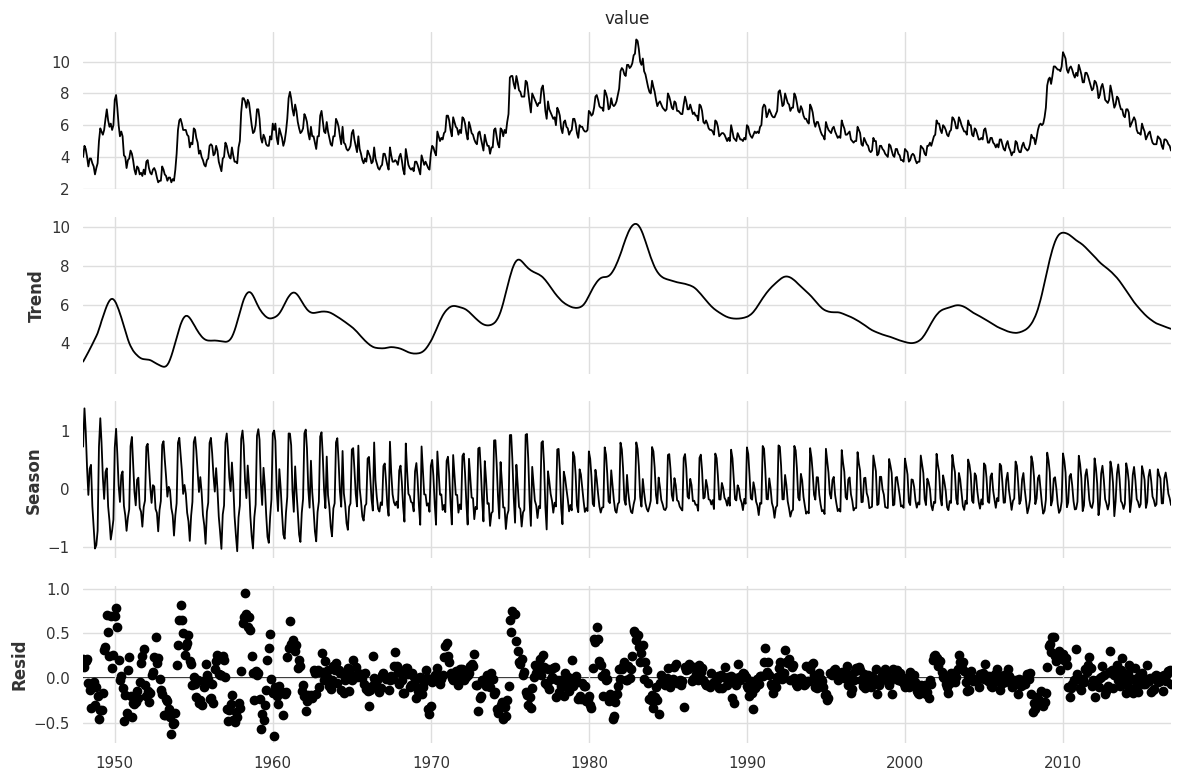

In [33]:
df = unemp_rate.to_dataframe().iloc[:, 0]
stl = tsa.STL(df)
res = stl.fit()
res.plot();

In [34]:
def add_robust(res, axes):
  for ax, comp in zip(axes[1:], ["trend", "seasonal", "resid"]):
      series = getattr(res, comp)
      if comp == "resid":
          ax.plot(series, marker="o", linestyle="none")
      else:
          ax.plot(series)
          if comp == "trend":
              ax.legend(["Non-robust", "Robust"], frameon=False)

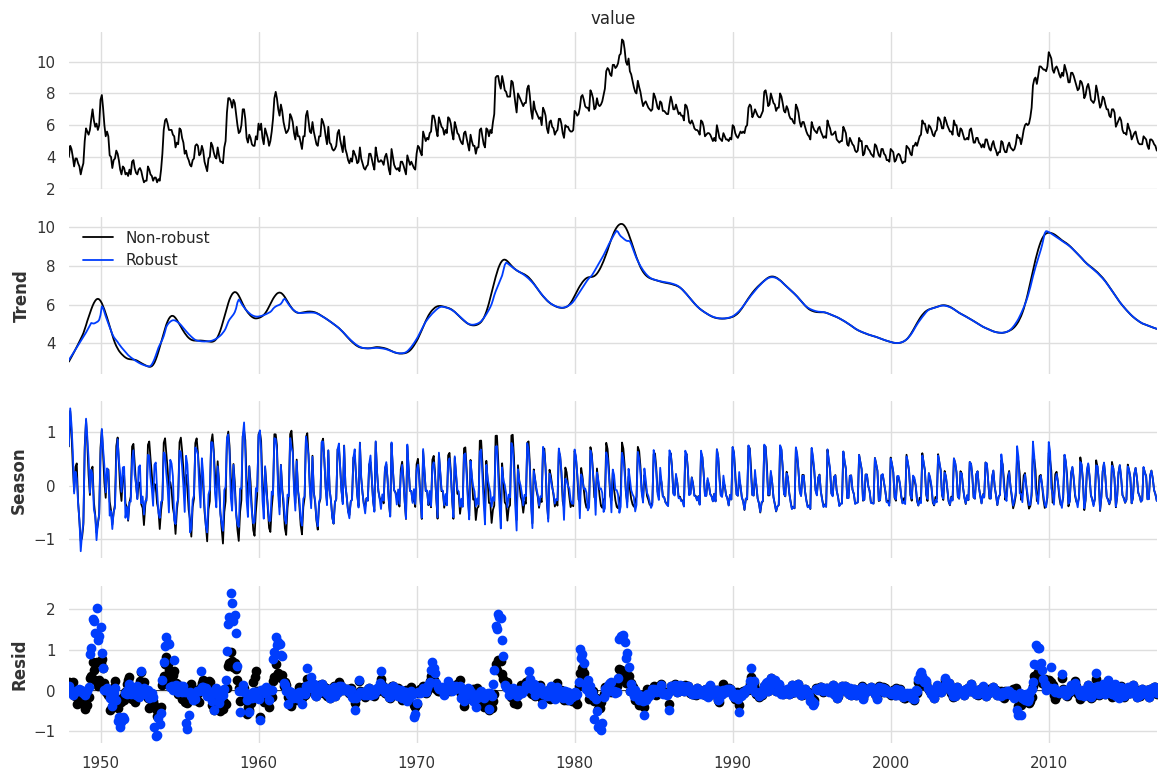

In [35]:
stl_robust = tsa.STL(df, robust=True)
res_robust = stl_robust.fit()
fig = res.plot();
add_robust(res_robust, fig.get_axes());

## MSTL decomposition

In [36]:
from statsmodels.tsa.seasonal import MSTL

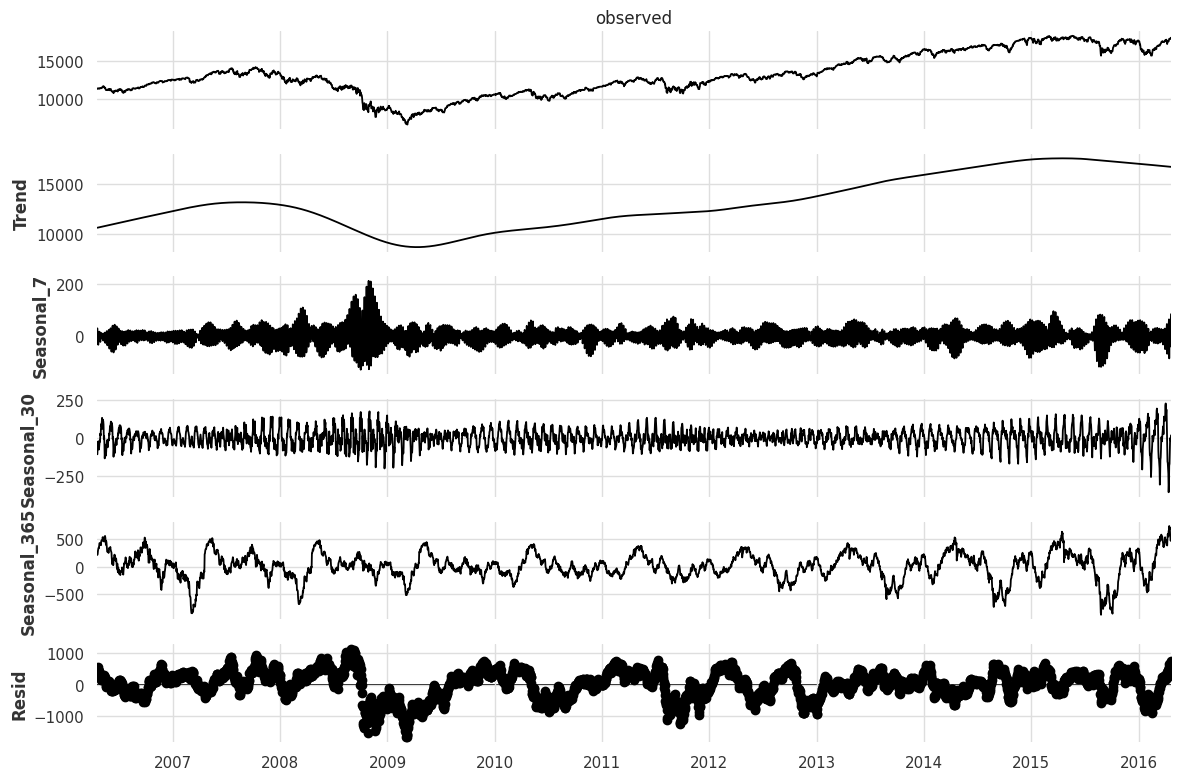

In [83]:
df = dow_jones.to_dataframe().iloc[:, 0]
mstl = MSTL(df, periods=[7, 30, 365])
res = mstl.fit()
res.plot();

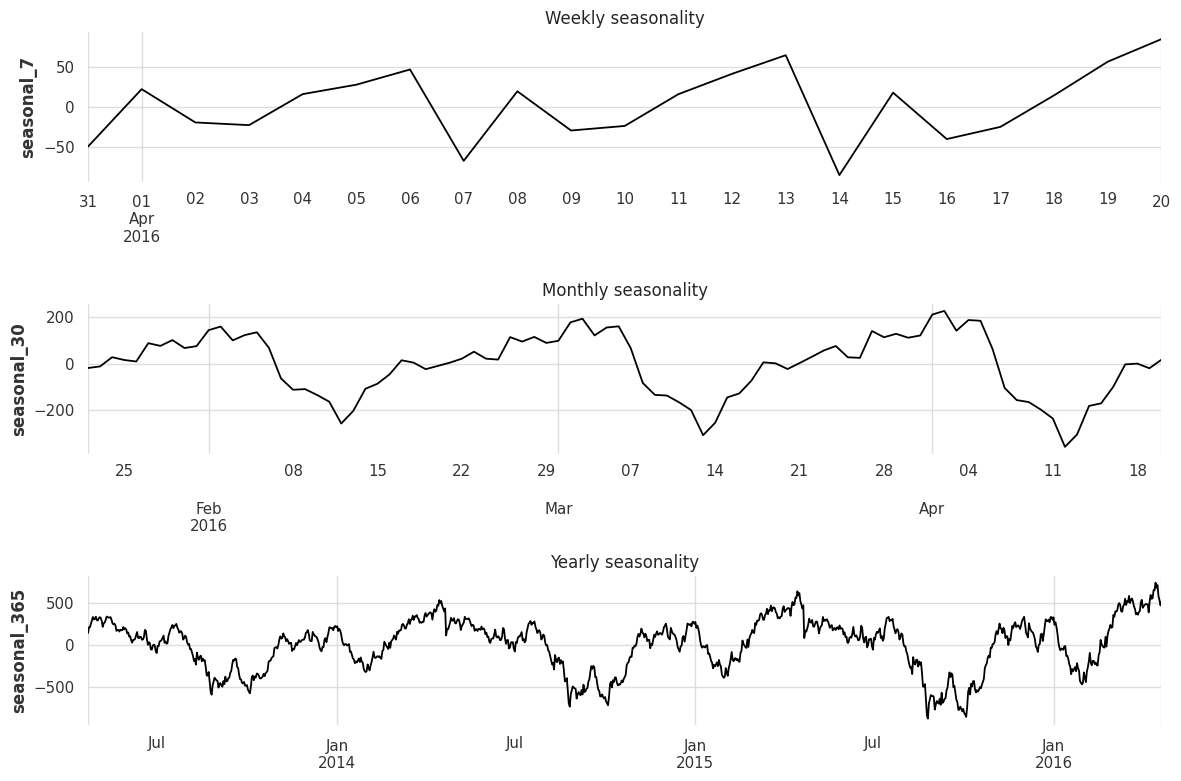

In [87]:
fig, ax = plt.subplots(3, 1)
res.seasonal["seasonal_7"].iloc[-7 * 3:].plot(ax=ax[0])
ax[0].set_ylabel("seasonal_7")
ax[0].set_title("Weekly seasonality")

res.seasonal["seasonal_30"].iloc[-30 * 3:].plot(ax=ax[1])
ax[1].set_ylabel("seasonal_30")
ax[1].set_title("Monthly seasonality")

res.seasonal["seasonal_365"].iloc[-365 * 3:].plot(ax=ax[2])
ax[2].set_ylabel("seasonal_365")
ax[2].set_title("Yearly seasonality")

plt.tight_layout()

## Reminder: SARIMA hyperparameters

SARIMA(p, d, q) x (P, D, Q):
$$
\begin{aligned}
X_t = & \alpha_0 + \alpha_1 X_{t-1} + \ldots + \alpha_p X_{t-p} + Z_t + \beta_1 Z_{t-1} + \ldots + \beta_q Z_{t-q} + \\
& + \alpha_S X_{t-S} + \alpha_{2S} X_{t-2S} + \ldots + \alpha_{PS} X_{t-PS} + \\
& + \beta_S Z_{t-S} + \beta_{2S} Z_{t-2S} + \ldots + \beta_{PS} Z_{t-QS}
\end{aligned}
$$

Hyperparameters:
- $d, D$
- $q, Q$
- $p, P$

## Reminder: differencing order estimation

In [92]:
import warnings

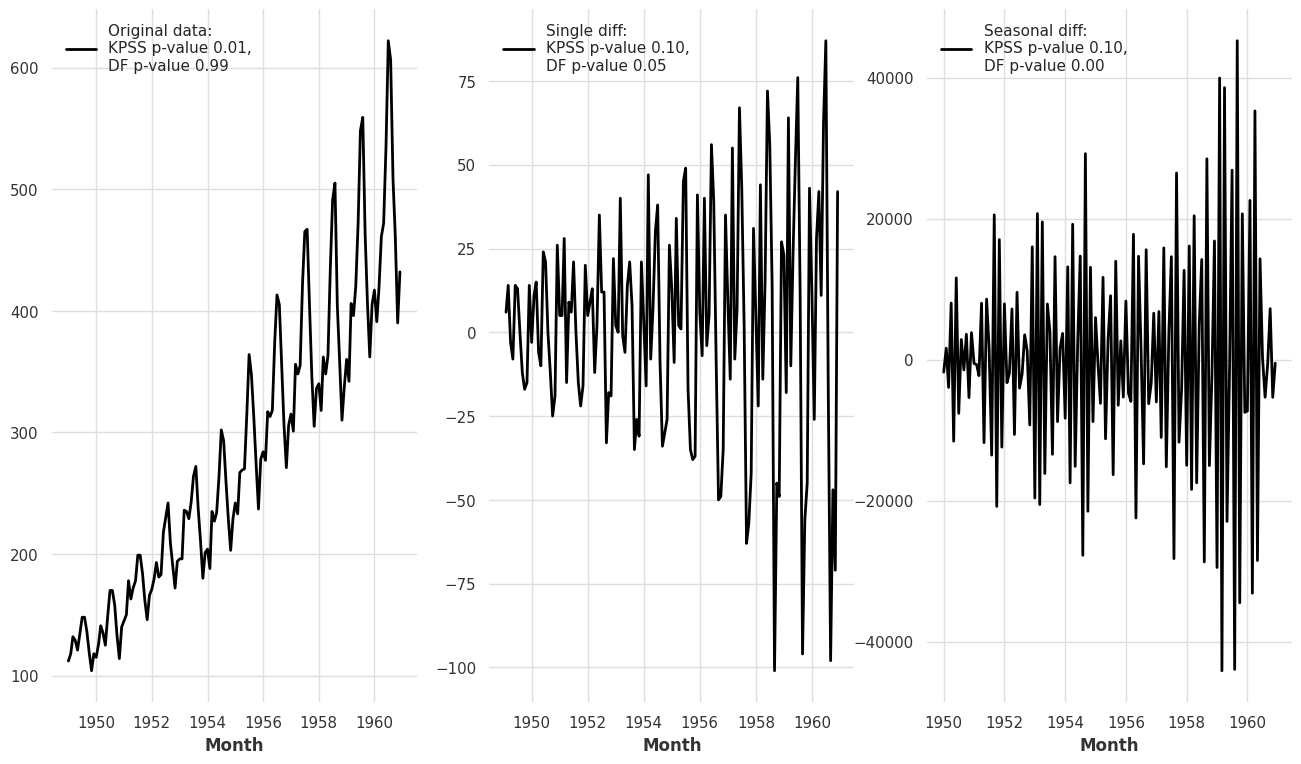

In [95]:
fig, ax = plt.subplots(1,3,figsize=(16,9))

with warnings.catch_warnings():
  air_pax.plot(ax=ax[0], label=f"Original data:\nKPSS p-value {tsa.stattools.kpss(air_pax.values())[1]:.2f},\nDF p-value {tsa.stattools.adfuller(air_pax.values())[1]:.2f}");
  air_pax.diff().plot(ax=ax[1], label=f"Single diff:\nKPSS p-value {tsa.stattools.kpss(air_pax.diff().values())[1]:.2f},\nDF p-value {tsa.stattools.adfuller(air_pax.diff().values())[1]:.2f}");
  air_pax.diff(12).plot(ax=ax[2], label=f"Seasonal diff:\nKPSS p-value {tsa.stattools.kpss(air_pax.diff(12).values())[1]:.2f},\nDF p-value {tsa.stattools.adfuller(air_pax.diff(12).values())[1]:.2f}");

## Reminder: sample autocorrelation and correlogram

Sample autocorrelation at lag $k$:
$$
r_k = \frac{\sum_{t=1}^{T-k} (x_t - \bar{x}) (x_{t_k} - \bar{x})}{\sum_{t=1}^{T} (x_t - \bar{x})^2}
$$

A correlogram is a plot of the sample autocorrelation coefficients $r_k$ against the lag $k$.

- We know that for $MA(q)$ process, the ACF becomes zero after $q$ lags.
- We also know that for $AR(p)$ process, the ACF is a mixture of exponential decay and sinusoid.
- It can be shown that the PACF has reverse properties to those above.

So by looking at ACF we define the order $q$ and by looking at PACF we define the order $p$.

Also the seaonal order can be defined, the lags will be significant at $P \cdot S$ and $Q \cdot S$.

## Estimation of p and q



In [154]:
ts = unemp_rate[pd.Timestamp("20100101"):]

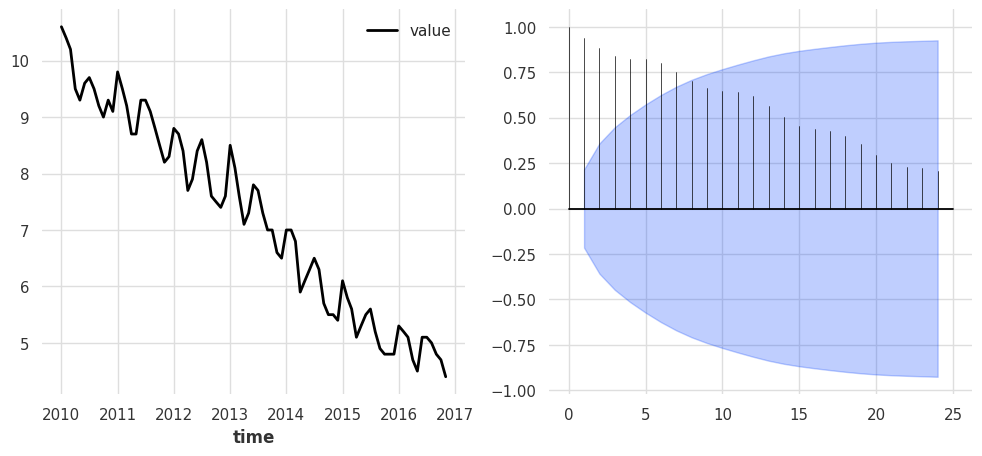

In [155]:
fig, ax = plt.subplots(1,2,figsize=(12, 5))
ts.plot(ax=ax[0])
plot_acf(ts, axis=ax[1])

In [156]:
check_seasonality(ts)

(False, 0)

S = 12

D = 1

d = 0

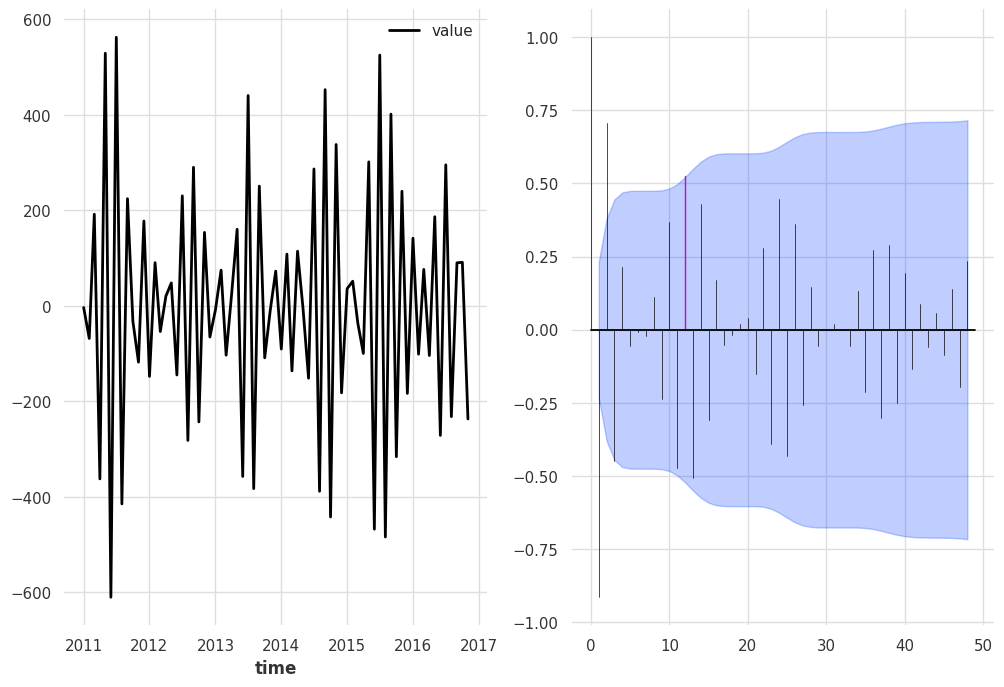

In [160]:
ts_diff = ts.diff(12)
fig, ax = plt.subplots(1,2,figsize=(12, 8))
ts_diff.plot(ax=ax[0])
plot_acf(ts_diff, axis=ax[1], max_lag=48, m=1 * 12)

Q = 1

q = 3

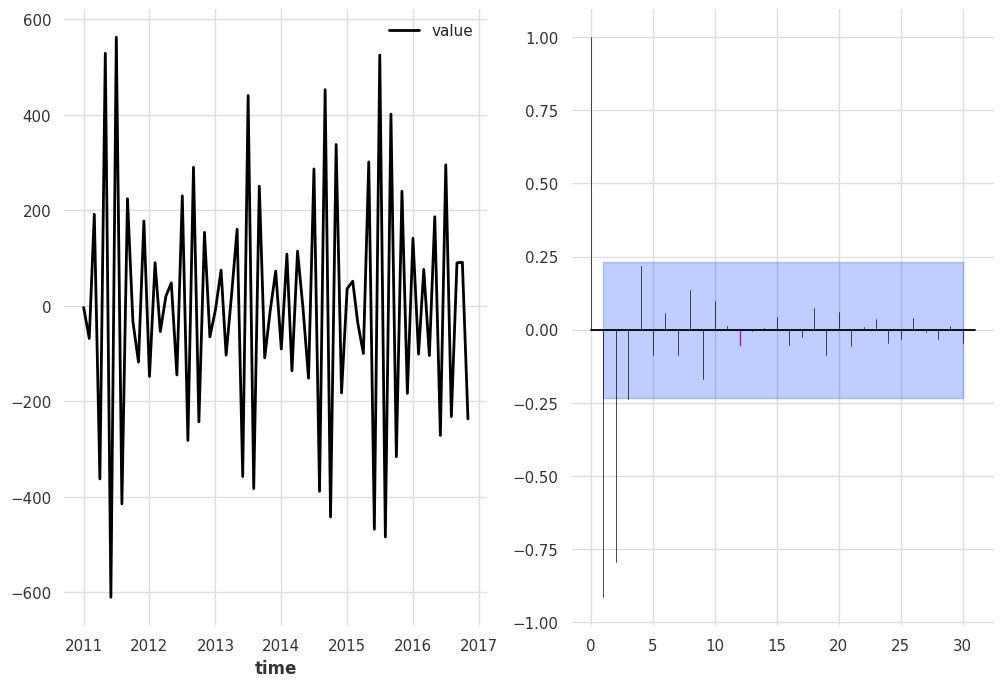

In [162]:
ts_diff = ts.diff(12)
fig, ax = plt.subplots(1,2,figsize=(12, 8))
ts_diff.plot(ax=ax[0])
plot_pacf(ts_diff, axis=ax[1], method="ywm", max_lag=30, m=12)

P = 0

p = 3

Overall: SARIMA(3, 0, 3)x(0, 1, 1)

In [164]:
from darts.models import ARIMA

In [166]:
train, test = ts.split_before(pd.Timestamp("20150101"))

In [216]:
arima = ARIMA(p=3, d=0, q=3, seasonal_order=(0, 1, 1, 12), trend="n")
arima.fit(train) # not ts_diff!
pred = arima.predict(len(test))

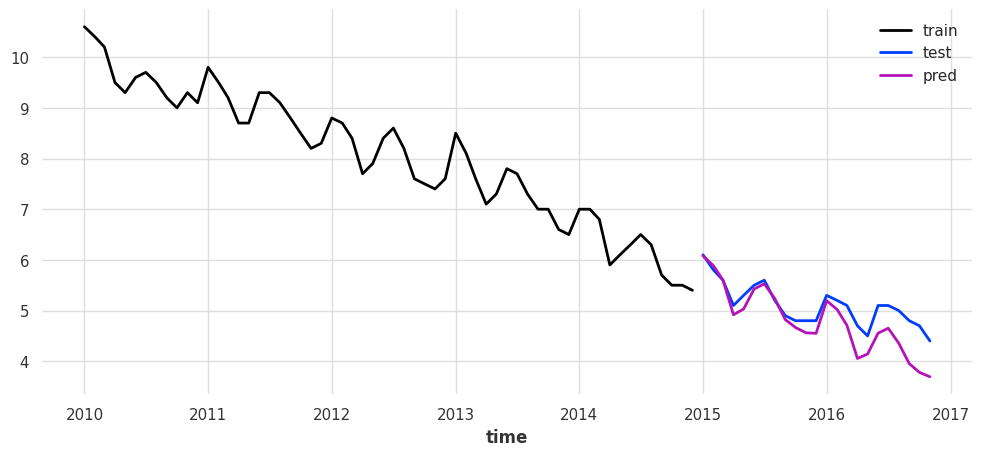

In [217]:
fig, ax = plt.subplots(figsize=(12,5))
train.plot(ax=ax, label="train")
test.plot(ax=ax, label="test")
pred.plot(ax=ax, label="pred");
ax.legend()

## Simple methods of forecasting

In [169]:
from darts.models import NaiveSeasonal, NaiveDrift, NaiveMean, NaiveMovingAverage

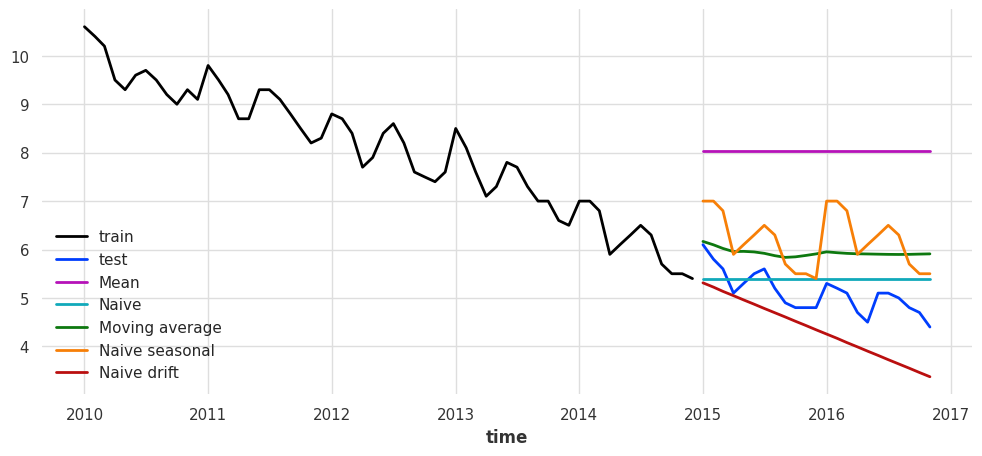

In [171]:
fig, ax = plt.subplots(figsize=(12,5))
train.plot(ax=ax, label="train")
test.plot(ax=ax, label="test")
NaiveMean().fit(train).predict(len(test)).plot(ax=ax, label="Mean");
NaiveSeasonal(K=1).fit(train).predict(len(test)).plot(ax=ax, label="Naive");
NaiveMovingAverage(input_chunk_length=12).fit(train).predict(len(test)).plot(ax=ax, label="Moving average");
NaiveSeasonal(K=12).fit(train).predict(len(test)).plot(ax=ax, label="Naive seasonal");
NaiveDrift().fit(train).predict(len(test)).plot(ax=ax, label="Naive drift");
ax.legend();

## Reminder: properties of residuals

Necessary
- Unbiasedness; to be checked with standard statistical tests for the mean, e.g. Student's t-test
- Stationarity; to be checked with visual analysis, KPSS test
- Uncorrelatedness; to be checked with correlogram, Ljung-Box-Pierce Q-criterion

Desired
- Normality; to be checked with QQ-plot, Shapiro test
- Homoscedacity; to be checked with visual analysis, Breusch–Pagan test

## Assessing properties of residuals

In [221]:
# approach 1
resid = arima.residuals(train)

In [173]:
# approach 2
arima_backtest = arima.historical_forecasts(
    series=train,
    start=train.time_index[24],
    forecast_horizon=1,
    stride=1,
    last_points_only=True,
    retrain=True,
    verbose=True
)
arima_resid = train.slice_intersect(arima_backtest) - arima_backtest

historical forecasts: 100%|██████████| 30/30 [00:42<00:00,  1.42s/it]


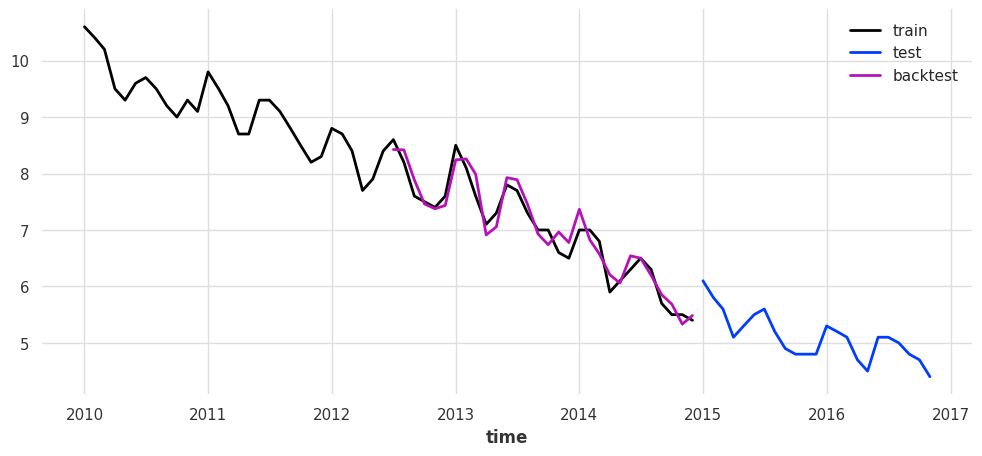

In [174]:
fig, ax = plt.subplots(figsize=(12,5))
train.plot(ax=ax, label="train")
test.plot(ax=ax, label="test")
arima_backtest.plot(ax=ax, label="backtest");
ax.legend()

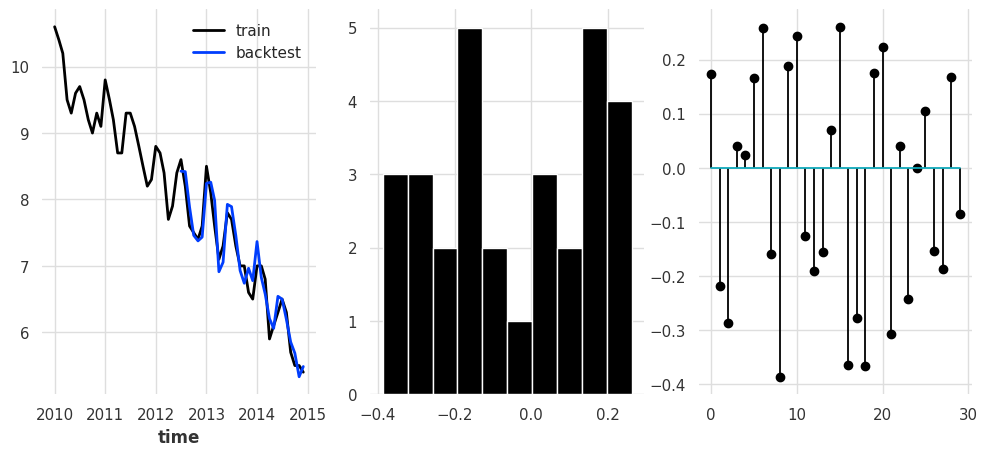

In [177]:
fig, ax = plt.subplots(1,3,figsize=(12,5))
train.plot(ax=ax[0], label="train")
arima_backtest.plot(ax=ax[0], label="backtest");
ax[1].hist(arima_resid.values());
ax[2].stem(arima_resid.values());
ax[0].legend();

In [178]:
pvalue = sts.ttest_1samp(arima_resid.values(), 0).pvalue
rejected = pvalue < 0.05
print("zero mean" if not rejected else "non-zero mean")

zero mean


In [179]:
pvalue = tsa.stattools.kpss(arima_resid.values())[1]
rejected = pvalue < 0.05
print("stationary" if not rejected else "non-stationary")

non-stationary


In [180]:
sm.stats.acorr_ljungbox(arima_resid.values(), model_df=1)["lb_pvalue"].max()
rejected = pvalue < 0.05
print("there is", "no autocorrelation" if not rejected else "autocorrelation")

there is autocorrelation


In [195]:
pvalue = sts.shapiro(arima_resid.values()).pvalue
rejected = pvalue < 0.05
print("normal" if not rejected else "not normal")

not normal


In [203]:
r = arima_resid.to_series()
trend = pd.Series(np.arange(len(r)), index=r.index, name="trend")
month_dums = pd.get_dummies(r.index.month.astype("category"), prefix="m", drop_first=True)
month_dums.index = r.index
X = pd.concat([trend, month_dums], axis=1)
X = sm.add_constant(X)
_, lm_pvalue, _, _ = sm.stats.diagnostic.het_breuschpagan(r.values, X.values) # null: does not depend
rejected = lm_pvalue < 0.05
print("homoscedastic" if not rejected else "heteroscedastic")

homoscedastic


In [204]:
def test_residuals(resid):
  fig, ax = plt.subplots(1,2,figsize=(12,5))
  ax[0].hist(resid.values());
  ax[1].stem(resid.values());
  plt.show();

  pvalue = sts.ttest_1samp(resid.values(), 0).pvalue
  rejected = pvalue < 0.05
  print("zero mean" if not rejected else "non-zero mean")

  pvalue = tsa.stattools.kpss(resid.values())[1]
  rejected = pvalue < 0.05
  print("stationary" if not rejected else "non-stationary")

  sm.stats.acorr_ljungbox(resid.values(), model_df=1)["lb_pvalue"].max()
  rejected = pvalue < 0.05
  print("there is", "no autocorrelation" if not rejected else "autocorrelation")

  pvalue = sts.shapiro(resid.values()).pvalue
  rejected = pvalue < 0.05
  print("normal" if not rejected else "not normal")

  r = resid.to_series()
  trend = pd.Series(np.arange(len(r)), index=r.index, name="trend")
  month_dums = pd.get_dummies(r.index.month.astype("category"), prefix="m", drop_first=True)
  month_dums.index = r.index
  X = pd.concat([trend, month_dums], axis=1)
  X = sm.add_constant(X)
  _, lm_pvalue, _, _ = sm.stats.diagnostic.het_breuschpagan(r.values, X.values) # null: does not depend
  rejected = lm_pvalue < 0.05
  print("homoscedastic" if not rejected else "heteroscedastic")

## AutoARIMA

In [182]:
from darts.models import AutoARIMA

In [192]:
auto_arima = AutoARIMA(seasonal=True, season_length=12)
auto_arima.fit(train)
pred = arima.predict(len(test))

In [193]:
p, q, P, Q, m, d, D = auto_arima.model.model_["arma"]
(p, d, q, P, D, Q)

(1, 1, 1, 1, 1, 0)

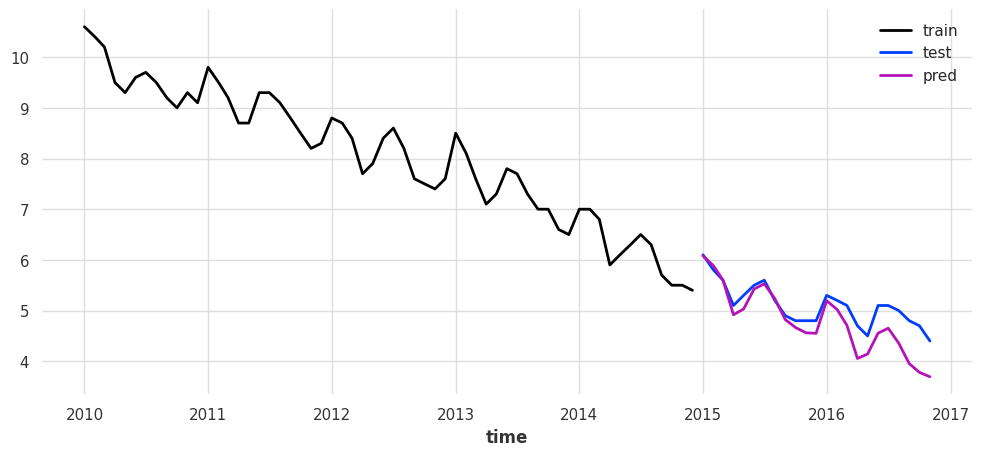

In [194]:
fig, ax = plt.subplots(figsize=(12,5))
train.plot(ax=ax, label="train")
test.plot(ax=ax, label="test")
pred.plot(ax=ax, label="pred");
ax.legend()

In [198]:
best_arima = ARIMA(p, d, q, seasonal_order=(P, D, Q, m), trend="n")

In [199]:
auto_arima_backtest = best_arima.historical_forecasts(
    series=train,
    start=train.time_index[24],
    forecast_horizon=1,
    stride=1,
    last_points_only=True,
    retrain=True,
    verbose=True
)
auto_arima_resid = train.slice_intersect(auto_arima_backtest) - auto_arima_backtest

historical forecasts: 100%|██████████| 30/30 [00:14<00:00,  2.08it/s]


## Residuals of AutoARIMA

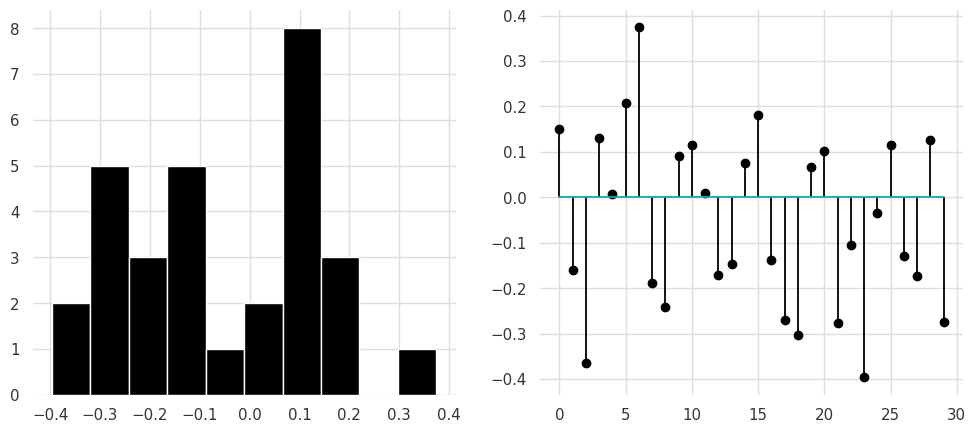

zero mean
stationary
there is no autocorrelation
normal
homoscedastic


In [205]:
test_residuals(auto_arima_resid)

## STLForecast

In [211]:
stl_model = tsa.STLForecast(
    train.to_series(),
    tsa.SARIMAX,
    period=12,
    model_kwargs=dict(order=(1, 1, 1), seasonal_order=(1, 1, 0, 12), trend="n")
)
fitted_stl_model = stl_model.fit()
stl_fcast = TimeSeries.from_series(fitted_stl_model.forecast(len(test)))

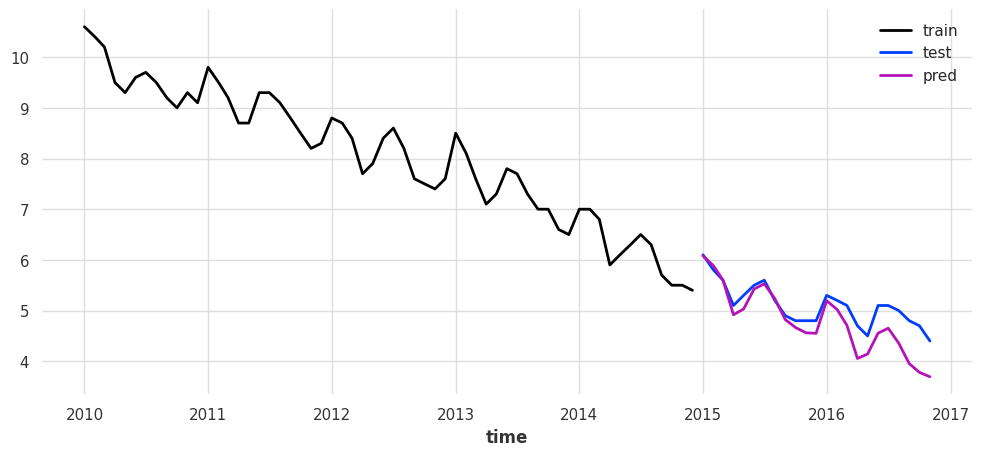

In [212]:
fig, ax = plt.subplots(figsize=(12,5))
train.plot(ax=ax, label="train")
test.plot(ax=ax, label="test")
pred.plot(ax=ax, label="pred");
ax.legend()